# LEP-eから電子の温度と流速を算出してみる。

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

In [14]:
import pyspedas as psp
import pytplot as pt

pt.del_data('*')

trange = ['2022-09-01/22:20:00', '2022-09-01/23:40:00']
trange_plot = ['2022-09-01/22:30:00', '2022-09-01/23:30:00']

psp.erg.lepe(trange=trange, datatype='3dflux', level='l2')

psp.erg.mgf(trange=trange, level='l2', datatype='64hz', coord='dsi')
psp.erg.orb(trange=trange, level='l2', datatype='def')

# 3) モーメント出力
psp.projects.erg.erg_lep_part_products(
    'erg_lepe_l2_3dflux_FEDU',
    outputs=['moments'],
    mag_name='erg_mgf_l2_mag_64hz_dsi',
    pos_name='erg_orb_l2_pos_dsi'
)


22-Jul-25 23:03:29: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/lepe/l2/3dflux/2022/09/
22-Jul-25 23:03:29: File is current: /mnt/j/observation_data//ergsc/satellite/erg/lepe/l2/3dflux/2022/09/erg_lepe_l2_3dflux_20220901_v04_01.cdf
22-Jul-25 23:03:34: Variable FEDU DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
22-Jul-25 23:03:35: Variable Count_Rate DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
22-Jul-25 23:03:35: Variable Count_Rate_BG DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
22-Jul-25 23:03:37: erg_lepe_l2_3dflux_FEDU contains negative values; setting the z-axis to log scale will cause the negative values to be ignored on figures.
22-Jul-25 23:03:37: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/64hz/2022/09/


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Low-Energy Particle experiments - electron analyzer (LEP-e) Level 2 3D electron flux data']

Information about ERG LEPe

PI:  ['Shiang-Yu Wang']
Affiliation:  ['Academia Sinica, Taiwan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPe L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepe

Contact: erg_lepe_info at isee.nagoya-u.ac.jp
**************************************************************************


22-Jul-25 23:03:39: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090122_v04.05.cdf
22-Jul-25 23:03:39: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090123_v04.05.cdf
22-Jul-25 23:03:40: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2022/


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


22-Jul-25 23:03:40: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


22-Jul-25 23:03:43: erg_mgf_l2_mag_64hz_dsi copied to erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:03:43: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:03:45: wildcard_expand: No match found for erg_lepe_l2_3dflux_FEDU_eflux
22-Jul-25 23:03:45: wildcard_expand: No match found for erg_lepe_l2_3dflux_FEDU_eflux


['erg_lepe_l2_3dflux_FEDU_density',
 'erg_lepe_l2_3dflux_FEDU_flux',
 'erg_lepe_l2_3dflux_FEDU_mftens',
 'erg_lepe_l2_3dflux_FEDU_velocity',
 'erg_lepe_l2_3dflux_FEDU_ptens',
 'erg_lepe_l2_3dflux_FEDU_ttens',
 'erg_lepe_l2_3dflux_FEDU_vthermal',
 'erg_lepe_l2_3dflux_FEDU_avgtemp']

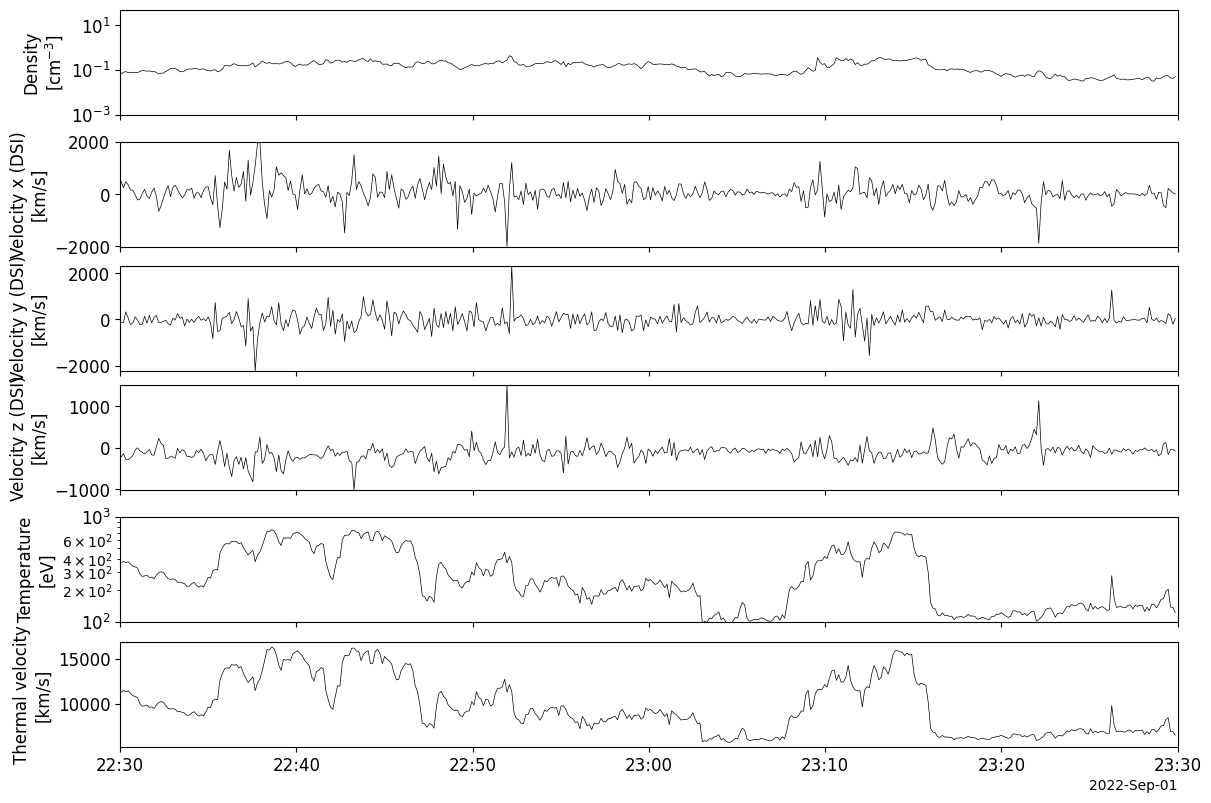

In [20]:
import pytplot as pt

# 描画対象をまとめて列挙

pt.tplot_math.split_vec('erg_lepe_l2_3dflux_FEDU_velocity')

vars_mom = [
    'erg_lepe_l2_3dflux_FEDU_density',  # scalar (cm^-3)
    'erg_lepe_l2_3dflux_FEDU_velocity_x',  # scalar (km/s)
    'erg_lepe_l2_3dflux_FEDU_velocity_y',  # scalar (km/s)
    'erg_lepe_l2_3dflux_FEDU_velocity_z',  # scalar (km/s)
    'erg_lepe_l2_3dflux_FEDU_avgtemp',   # scalar (eV)
    'erg_lepe_l2_3dflux_FEDU_vthermal',  # scalar (km/s)
]

for xyz in ['x', 'y', 'z']:
    v_out = f'erg_lepe_l2_3dflux_FEDU_velocity_{xyz}'
    pt.options(v_out, 'ytitle', f'Velocity {xyz} (DSI)')
    pt.options(v_out, 'ysubtitle', '[km/s]')

pt.options('erg_lepe_l2_3dflux_FEDU_density', 'ytitle', 'Density')
pt.options('erg_lepe_l2_3dflux_FEDU_density', 'ysubtitle', '[cm$^{-3}$]')
pt.options('erg_lepe_l2_3dflux_FEDU_avgtemp', 'ylog', True)
pt.options('erg_lepe_l2_3dflux_FEDU_avgtemp', 'ytitle', 'Temperature')
pt.options('erg_lepe_l2_3dflux_FEDU_avgtemp', 'yrange', [1E2, 1E3])
pt.options('erg_lepe_l2_3dflux_FEDU_avgtemp', 'ysubtitle', '[eV]')
pt.options('erg_lepe_l2_3dflux_FEDU_vthermal', 'ytitle', 'Thermal velocity')
pt.options('erg_lepe_l2_3dflux_FEDU_vthermal', 'ysubtitle', '[km/s]')

# 全パネル一括表示（色付きテンソルは自動でスペクトログラム形式になる）
pt.tplot(vars_mom, trange=trange_plot)


In [16]:
Vx = pt.data_quants['erg_lepe_l2_3dflux_FEDU_velocity_x']

Vx

<xarray.DataArray 'erg_lepe_l2_3dflux_FEDU_velocity_x' (time: 599)> Size: 5kB
array([ 1.33448253e+02,  4.17638180e+01, -3.05360613e+02,  6.93299481e+01,
        2.95383634e+02,  6.69258730e+02,  1.91553124e+01,  8.13404306e+01,
        1.80015893e+02, -2.11242481e+01, -4.51052847e+01, -3.63565068e+01,
       -1.11615018e+02, -2.28219211e+01, -1.97877762e+01,  7.30070914e+01,
        1.17749926e+02, -5.87977204e+01,  3.09158361e+01, -1.44833349e+02,
       -6.23797250e+01,  8.86852825e+00,  2.25868080e+02,  6.03541536e+01,
        8.06840261e+01,  2.94686582e+02,  1.04834749e+01,  3.95069340e+01,
        1.82348869e+02,  8.86384583e+01,  4.34648342e+01,  2.85126081e+00,
        1.70931089e+02, -5.64440014e+01, -1.23004974e+02,  9.15226455e+01,
        3.67236884e+02,  6.09521758e+01, -9.33625922e+01,  1.32134215e+02,
        3.25092166e+02, -6.73781900e+00,  1.18599164e+02, -2.07971721e+00,
        1.11661080e+01,  3.72953767e+01, -4.64486353e+00,  1.49388318e+02,
        6.52795862e+01,  1.09758520e+02,  1.21035424e+02,  1.16292277e+02,
       -7.51742833e+01, -3.79703816e+01,  6.98854474e+01,  2.99769382e+02,
        7.46064419e+02,  4.95980210e+02,  1.43115483e+00,  7.37146118e+02,
        1.88163223e+02,  4.70260874e+02,  2.63764337e+02,  4.76245433e+02,
       -1.33286840e+02,  4.45633804e+02,  8.26765727e+02, -1.53655121e+02,
        3.19246404e+02,  9.45159382e+01,  2.17127417e+02, -1.62230256e+02,
        1.30548046e+01,  2.51118902e+02,  2.20647133e+02,  4.96052672e+02,
        2.51829353e+02,  4.78222047e+02,  3.62765681e+02,  1.62569893e+02,
...
        2.25161301e+02,  1.29995457e+02,  5.64167638e+01,  1.04013160e+01,
        1.10774626e+02,  1.96323011e+02, -8.65858257e+01,  1.06464114e+02,
        3.37492123e+01,  7.78473792e+01,  3.40554126e+01,  4.03479605e+01,
        1.53528456e+02, -4.59415983e+01,  2.52476102e+01,  9.97412642e+01,
        1.30469580e+02,  2.29062899e+01,  1.22488747e+01,  4.30545960e+01,
        4.48066635e+01,  1.52179705e+02, -7.21413289e+01,  7.82058651e+01,
       -4.69016397e+01,  8.45156731e+01,  1.54009105e+02,  6.49979686e+01,
        2.33270191e+00,  2.67398434e+01,  5.67859343e+01,  1.31612733e+02,
        3.11699664e+01,  4.62847385e+01,  1.66638754e+02, -2.63638609e+01,
       -1.43201935e+02,  2.58441384e+01,  2.23507133e+01,  3.42459269e+01,
        5.16874795e+01,  9.28900056e+01,  2.67080423e+01, -5.27905082e+01,
       -9.30320185e+00,  8.94694121e+01, -3.66139473e+01,  2.94707879e+01,
        4.45711006e+00,  8.69741817e+01,  8.00565689e+01,  8.82227509e+01,
       -1.19997151e+02,  2.11458771e+01,  1.33221849e+02,  2.10296405e+01,
       -5.07244436e+01, -2.10623660e+01, -8.54307062e+01, -1.57398647e+02,
       -4.09281419e+01, -5.27424522e+01, -8.57177909e-01,  3.50532215e+02,
        3.16850599e+01,  9.44633173e+01, -2.52480686e+01,  1.53950411e+02,
       -7.29781742e+01,  1.94657647e+02,  2.74739946e+02, -1.44747660e+02,
       -2.00908700e+02,  1.60669926e+02, -5.96045367e+01, -9.66305672e+01,
       -2.48663428e+02, -1.64111632e+02, -9.28798358e+01])
Coordinates:
  * time     (time) datetime64[ns] 5kB 2022-09-01T22:20:02.693905920 ... 2022...
Attributes:
    plot_options:  {'xaxis_opt': {'axis_label': '', 'crosshair': 'X', 'x_axis...

## LEP-iからionのmomentを算出

22-Jul-25 23:11:21: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/lepi/l2/3dflux/2022/09/
22-Jul-25 23:11:22: File is current: /mnt/j/observation_data//ergsc/satellite/erg/lepi/l2/3dflux/2022/09/erg_lepi_l2_3dflux_20220901_v03_00.cdf
22-Jul-25 23:11:30: Variable FPDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
22-Jul-25 23:11:32: Variable FHEDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
22-Jul-25 23:11:33: Variable FODU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
22-Jul-25 23:11:34: store_data: Data array for variable erg_lepi_l2_3dflux_FPDU_Quality has 4 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
22-Jul-25 23:11:34: store_data: Data array for variable erg_lepi_l2_3dflux_FHEDU_Quality has 4 dim

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Low Energy Particle Ion (LEPi) Experiment 3D ion flux data']

Information about ERG LEPi

PI:  ['Kazushi Asamura']
Affiliation:  ['ISAS, Jaxa']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPi L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi
RoR of ERG/LEPi: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepi#Rules_of_the_Road

Contact: erg_lepi_info at isee.nagoya-u.ac.jp
**************************************************************************


22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FHEDU_sub copied to erg_lepi_l2_3dflux_FHEDU_sub_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FODU copied to erg_lepi_l2_3dflux_FODU_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FODU_sub copied to erg_lepi_l2_3dflux_FODU_sub_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FPEDU copied to erg_lepi_l2_3dflux_FPEDU_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FPEDU_sub copied to erg_lepi_l2_3dflux_FPEDU_sub_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FHEEDU copied to erg_lepi_l2_3dflux_FHEEDU_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FHEEDU_sub copied to erg_lepi_l2_3dflux_FHEEDU_sub_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FOEDU copied to erg_lepi_l2_3dflux_FOEDU_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FOEDU_sub copied to erg_lepi_l2_3dflux_FOEDU_sub_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FPDU_COUNT_RAW copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_raw
22-Jul-25 23:11:36: erg_lepi_l2_3dflux_FPDU_COUNT_RAW_sub copied to erg_lepi_l2_3dflux_FPDU_COUNT_RAW_

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


22-Jul-25 23:11:40: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
22-Jul-25 23:11:40: erg_mgf_l2_mag_64hz_dsi copied to erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:11:40: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_dsi_pgs_temp


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


22-Jul-25 23:11:40: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/pyspedas/particles/moments/moments_3d.py:122: RuntimeWarning: invalid value encountered in divide
  velocity = flux/density/1e5 # km/s

22-Jul-25 23:11:45: erg_lepi_l2_3dflux_FPDU is 39% done.
22-Jul-25 23:11:50: erg_lepi_l2_3dflux_FPDU is 79% done.
22-Jul-25 23:11:52: wildcard_expand: No match found for erg_lepi_l2_3dflux_FPDU_eflux
22-Jul-25 23:11:52: wildcard_expand: No match found for erg_lepi_l2_3dflux_FPDU_eflux


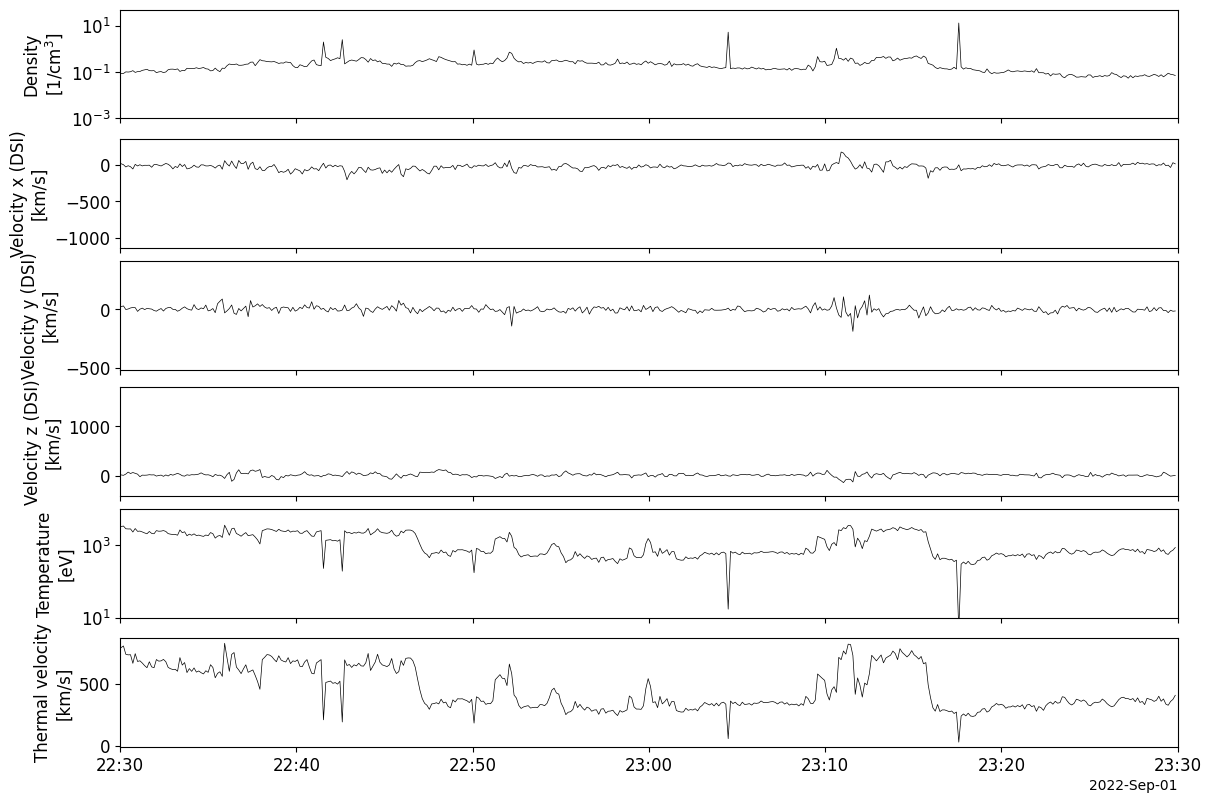

In [19]:
import pyspedas as psp
import pytplot as pt

trange = ['2022-09-01/22:20:00', '2022-09-01/23:40:00']
trange_plot = ['2022-09-01/22:30:00', '2022-09-01/23:30:00']

psp.erg.lepi(trange=trange, datatype='3dflux', level='l2')

psp.erg.mgf(trange=trange, level='l2', datatype='64hz', coord='dsi')
psp.erg.orb(trange=trange, level='l2', datatype='def')

# 3) モーメント出力
psp.projects.erg.erg_lep_part_products(
    'erg_lepi_l2_3dflux_FPDU',
    outputs=['moments'],
    mag_name='erg_mgf_l2_mag_64hz_dsi',
    pos_name='erg_orb_l2_pos_dsi'
)

pt.tplot_math.split_vec('erg_lepi_l2_3dflux_FPDU_velocity')

vars_mom = [
    'erg_lepi_l2_3dflux_FPDU_density',  # scalar (1/cm^3)
    'erg_lepi_l2_3dflux_FPDU_velocity_x',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FPDU_velocity_y',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FPDU_velocity_z',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FPDU_avgtemp',   # scalar (eV)
    'erg_lepi_l2_3dflux_FPDU_vthermal',  # scalar (km/s)
]

for xyz in ['x', 'y', 'z']:
    v_out = f'erg_lepi_l2_3dflux_FPDU_velocity_{xyz}'
    pt.options(v_out, 'ytitle', f'Velocity {xyz} (DSI)')
    pt.options(v_out, 'ysubtitle', '[km/s]')

pt.options('erg_lepi_l2_3dflux_FPDU_density', 'ytitle', 'Density')
pt.options('erg_lepi_l2_3dflux_FPDU_density', 'ysubtitle', '[1/cm^3]')
pt.options('erg_lepi_l2_3dflux_FPDU_avgtemp', 'ylog', True)
pt.options('erg_lepi_l2_3dflux_FPDU_avgtemp', 'ytitle', 'Temperature')
pt.options('erg_lepi_l2_3dflux_FPDU_avgtemp', 'yrange', [1E1, 1E4])
pt.options('erg_lepi_l2_3dflux_FPDU_avgtemp', 'ysubtitle', '[eV]')
pt.options('erg_lepi_l2_3dflux_FPDU_vthermal', 'ytitle', 'Thermal velocity')
pt.options('erg_lepi_l2_3dflux_FPDU_vthermal', 'ysubtitle', '[km/s]')

# 全パネル一括表示（色付きテンソルは自動でスペクトログラム形式になる）
pt.tplot(vars_mom, trange=trange_plot)

22-Jul-25 23:13:48: erg_mgf_l2_mag_64hz_dsi copied to erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:13:48: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:13:48: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/pyspedas/particles/moments/moments_3d.py:122: RuntimeWarning: invalid value encountered in divide
  velocity = flux/density/1e5 # km/s

22-Jul-25 23:13:53: erg_lepi_l2_3dflux_FHEDU is 40% done.
22-Jul-25 23:13:58: erg_lepi_l2_3dflux_FHEDU is 80% done.
22-Jul-25 23:14:01: wildcard_expand: No match found for erg_lepi_l2_3dflux_FHEDU_eflux
22-Jul-25 23:14:01: wildcard_expand: No match found for erg_lepi_l2_3dflux_FHEDU_eflux


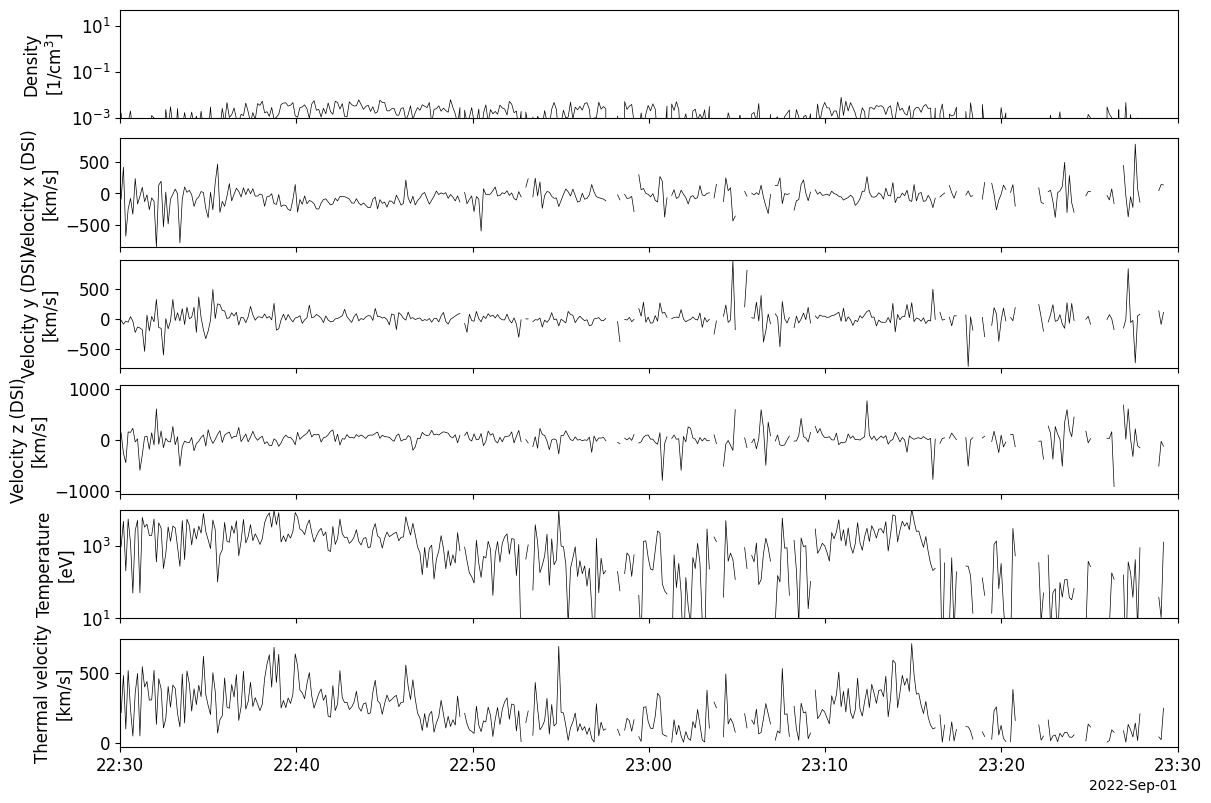

In [21]:
import pyspedas as psp
import pytplot as pt

psp.projects.erg.erg_lep_part_products(
    'erg_lepi_l2_3dflux_FHEDU',
    outputs=['moments'],
    mag_name='erg_mgf_l2_mag_64hz_dsi',
    pos_name='erg_orb_l2_pos_dsi'
)

pt.tplot_math.split_vec('erg_lepi_l2_3dflux_FHEDU_velocity')

vars_mom = [
    'erg_lepi_l2_3dflux_FHEDU_density',  # scalar (1/cm^3)
    'erg_lepi_l2_3dflux_FHEDU_velocity_x',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FHEDU_velocity_y',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FHEDU_velocity_z',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FHEDU_avgtemp',   # scalar (eV)
    'erg_lepi_l2_3dflux_FHEDU_vthermal',  # scalar (km/s)
]

for xyz in ['x', 'y', 'z']:
    v_out = f'erg_lepi_l2_3dflux_FHEDU_velocity_{xyz}'
    pt.options(v_out, 'ytitle', f'Velocity {xyz} (DSI)')
    pt.options(v_out, 'ysubtitle', '[km/s]')

pt.options('erg_lepi_l2_3dflux_FHEDU_density', 'ytitle', 'Density')
pt.options('erg_lepi_l2_3dflux_FHEDU_density', 'ysubtitle', '[1/cm^3]')
pt.options('erg_lepi_l2_3dflux_FHEDU_avgtemp', 'ylog', True)
pt.options('erg_lepi_l2_3dflux_FHEDU_avgtemp', 'ytitle', 'Temperature')
pt.options('erg_lepi_l2_3dflux_FHEDU_avgtemp', 'yrange', [1E1, 1E4])
pt.options('erg_lepi_l2_3dflux_FHEDU_avgtemp', 'ysubtitle', '[eV]')
pt.options('erg_lepi_l2_3dflux_FHEDU_vthermal', 'ytitle', 'Thermal velocity')
pt.options('erg_lepi_l2_3dflux_FHEDU_vthermal', 'ysubtitle', '[km/s]')

# 全パネル一括表示（色付きテンソルは自動でスペクトログラム形式になる）
pt.tplot(vars_mom, trange=trange_plot)

22-Jul-25 23:14:59: erg_mgf_l2_mag_64hz_dsi copied to erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:14:59: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_dsi_pgs_temp
22-Jul-25 23:14:59: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/pyspedas/particles/moments/moments_3d.py:122: RuntimeWarning: invalid value encountered in divide
  velocity = flux/density/1e5 # km/s

22-Jul-25 23:15:04: erg_lepi_l2_3dflux_FODU is 38% done.
22-Jul-25 23:15:09: erg_lepi_l2_3dflux_FODU is 78% done.
22-Jul-25 23:15:12: wildcard_expand: No match found for erg_lepi_l2_3dflux_FODU_eflux
22-Jul-25 23:15:12: wildcard_expand: No match found for erg_lepi_l2_3dflux_FODU_eflux


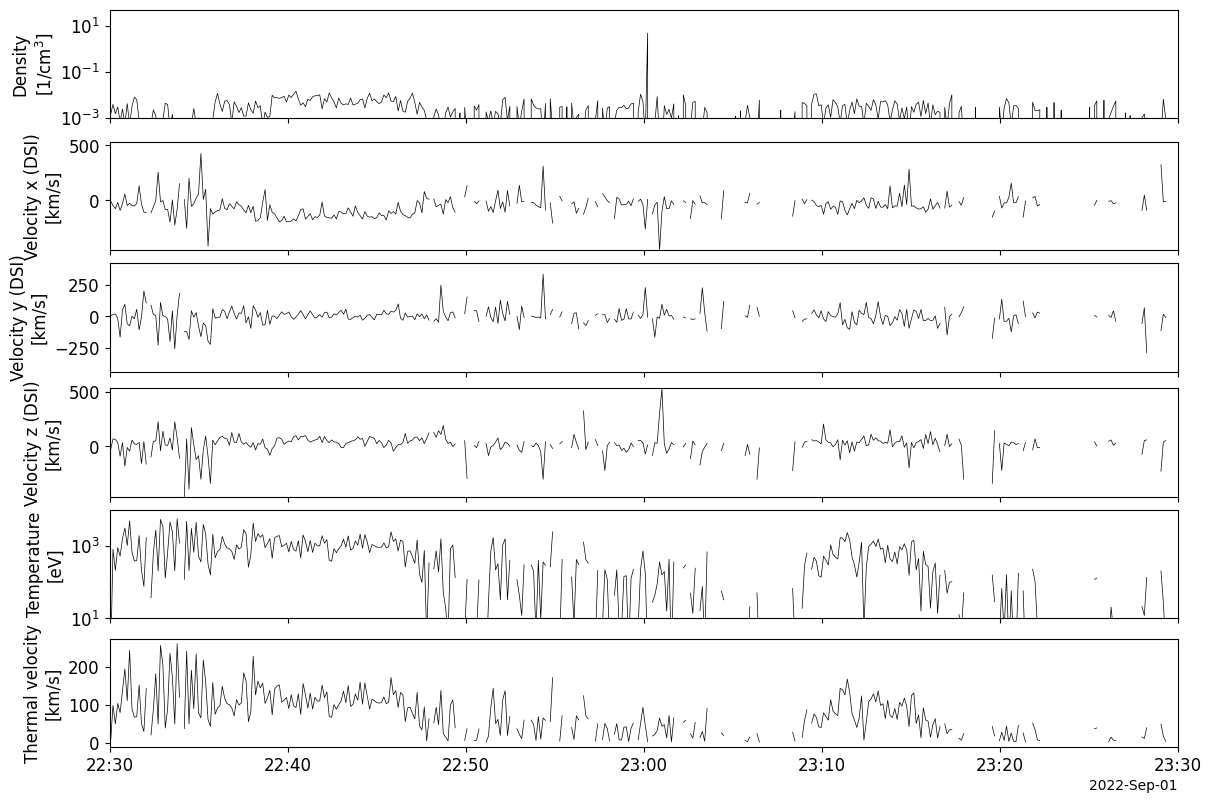

In [22]:
import pyspedas as psp
import pytplot as pt

psp.projects.erg.erg_lep_part_products(
    'erg_lepi_l2_3dflux_FODU',
    outputs=['moments'],
    mag_name='erg_mgf_l2_mag_64hz_dsi',
    pos_name='erg_orb_l2_pos_dsi'
)

pt.tplot_math.split_vec('erg_lepi_l2_3dflux_FODU_velocity')

vars_mom = [
    'erg_lepi_l2_3dflux_FODU_density',  # scalar (1/cm^3)
    'erg_lepi_l2_3dflux_FODU_velocity_x',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FODU_velocity_y',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FODU_velocity_z',  # scalar (km/s)
    'erg_lepi_l2_3dflux_FODU_avgtemp',   # scalar (eV)
    'erg_lepi_l2_3dflux_FODU_vthermal',  # scalar (km/s)
]

for xyz in ['x', 'y', 'z']:
    v_out = f'erg_lepi_l2_3dflux_FODU_velocity_{xyz}'
    pt.options(v_out, 'ytitle', f'Velocity {xyz} (DSI)')
    pt.options(v_out, 'ysubtitle', '[km/s]')

pt.options('erg_lepi_l2_3dflux_FODU_density', 'ytitle', 'Density')
pt.options('erg_lepi_l2_3dflux_FODU_density', 'ysubtitle', '[1/cm^3]')
pt.options('erg_lepi_l2_3dflux_FODU_avgtemp', 'ylog', True)
pt.options('erg_lepi_l2_3dflux_FODU_avgtemp', 'ytitle', 'Temperature')
pt.options('erg_lepi_l2_3dflux_FODU_avgtemp', 'yrange', [1E1, 1E4])
pt.options('erg_lepi_l2_3dflux_FODU_avgtemp', 'ysubtitle', '[eV]')
pt.options('erg_lepi_l2_3dflux_FODU_vthermal', 'ytitle', 'Thermal velocity')
pt.options('erg_lepi_l2_3dflux_FODU_vthermal', 'ysubtitle', '[km/s]')

# 全パネル一括表示（色付きテンソルは自動でスペクトログラム形式になる）
pt.tplot(vars_mom, trange=trange_plot)